<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/environment/11_03_26_Exercize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Definition of the problem
● Use the pulse library generated last time and train a DNN to remove the noise from the pulses

● What are the main parameters of a SiPM pulse like this?

**What ANN architecture could be used and
why?**

The Auto Encoder (AE)

> ● Goal: build a model that identifies fundamental characteristics in the input data

>> ○ In our case we aim to extract from the noisy pulse: raise time, decay time, time offset, etc

> ● Combine an encoder that converts input data in a different representation, with a decoder that converts the new representation back to the original input

> ● One option is:

>> ○ Noisy pulse as the input

>> ○ Pure pulse as the target

>> ○ The DNN learns the relevant features of the pulse

● Pulse library available [here](https://drive.google.com/drive/folders/1ZDrlUfoZpGJqPEsUvWRhJhM9zsODqoTV?usp=sharing)

In [2]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle


In [3]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
signal_waves_noisy_path = "/content/drive/MyDrive/Environment/PulseLibraryDataset/data/signal_waves_noisy.npy"
signal_waves_path = "/content/drive/MyDrive/Environment/PulseLibraryDataset/data/signal_waves.npy"

In [5]:
noisy_signal_data = np.load(signal_waves_noisy_path)
signal_data = np.load(signal_waves_path)

In [6]:
noisy_signal_data.shape, signal_data.shape

((200000, 2, 600), (200000, 2, 600))

In [7]:
noisy_signal_data[:2]

array([[[ 0.00000000e+00,  5.00000000e-01,  1.00000000e+00, ...,
          2.98500000e+02,  2.99000000e+02,  2.99500000e+02],
        [ 3.27060306e-02, -1.29916121e-01,  1.78229986e-02, ...,
         -3.74355941e-02, -3.84462985e-03, -1.11548768e-02]],

       [[ 0.00000000e+00,  5.00000000e-01,  1.00000000e+00, ...,
          2.98500000e+02,  2.99000000e+02,  2.99500000e+02],
        [ 4.79499384e-02, -1.21122205e-02, -1.15671931e-02, ...,
          6.97803002e-03,  6.32341978e-02,  3.71367494e-03]]])

In [8]:
signal_data[:2]

array([[[ 0.00000000e+00,  5.00000000e-01,  1.00000000e+00, ...,
          2.98500000e+02,  2.99000000e+02,  2.99500000e+02],
        [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
          1.66767826e-03,  1.64561659e-03,  1.62384678e-03]],

       [[ 0.00000000e+00,  5.00000000e-01,  1.00000000e+00, ...,
          2.98500000e+02,  2.99000000e+02,  2.99500000e+02],
        [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
          4.14565182e-03,  4.10313433e-03,  4.06105291e-03]]])

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(noisy_signal_data, signal_data, test_size=0.2, random_state=42)

In [11]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((160000, 2, 600), (160000, 2, 600), (40000, 2, 600), (40000, 2, 600))

## Create the mode


In [8]:
# Import tensorflow
import tensorflow as tf

In [13]:
tf.__version__

'2.19.0'

**1. Define the model**

In [14]:
# Define the model
model = tf.keras.Sequential()

**2. Add the model architechure**

In [15]:
# 1. Add input layer
model.add(tf.keras.Input(shape=(2, 600)))
# Flatt the signal
model.add(tf.keras.layers.Flatten())
# 2. Add first hidden layer
model.add(tf.keras.layers.Dense(units=3,
                                activation=tf.keras.activations.relu,
                                kernel_initializer=tf.keras.initializers.random_normal,
                                bias_initializer=tf.keras.initializers.zeros))
# Randomely turn of some neuron --> prevent overfitting
model.add(tf.keras.layers.Dropout(rate=0.2))# 20% of neurons are randomely ignored during training
# 3. Add second hidden layer
model.add(tf.keras.layers.Dense(units=3,
                                activation=tf.keras.activations.relu,
                                kernel_initializer=tf.keras.initializers.random_normal,
                                bias_initializer=tf.keras.initializers.zeros))
# 3. Add the output layer
model.add(tf.keras.layers.Dense(units=1200,
                                activation=tf.keras.activations.linear,
                                kernel_initializer=tf.keras.initializers.random_normal,
                                bias_initializer=tf.keras.initializers.zeros))
# 4. Reshape to the original signal
model.add(tf.keras.layers.Reshape((2,600)))  # back to signal shape

**3. Compile the model**


In [16]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=['mae'])

**4. Train the model**

In [17]:
X_train.shape, y_train.shape

((160000, 2, 600), (160000, 2, 600))

In [18]:
early_stoping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train, batch_size=64, epochs=50, callbacks=[early_stoping], validation_split=0.2)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 970.3107 - mae: 6.5875 - val_loss: 438.5075 - val_mae: 12.7471
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 179.0352 - mae: 2.3712 - val_loss: 327.1094 - val_mae: 10.9679
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.0837 - mae: 0.4764 - val_loss: 330.3087 - val_mae: 11.0196
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.5781 - mae: 0.3744 - val_loss: 392.6443 - val_mae: 12.0284
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 4.0593 - mae: 0.5114 - val_loss: 363.7300 - val_mae: 11.5641
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.9951 - mae: 0.3485 - val_loss: 392.1600 - val_mae: 11.9939
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2858 - mae: 0.1140 - val_loss: 675.9883 - val_mae: 15.8927
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 7.6080 - mae: 0.6333 - val_loss: 420.7363 - val_mae: 12.4245
Epoch 9/50
2

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,603 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1200)           │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 600)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,247 (98.62 KB)

 Trainable params: 8,415 (32.87 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,832 (65.75 KB)

**Save the model weights**

In [34]:
file_path = "/content/model.keras"
model.save(file_path)

**Save model history**

In [42]:
with open('history.pkl', 'wb') as f:
  pickle.dump(history.history, f)

**Load the saved model**

In [12]:
# Create a new model instance
model_path = "/content/drive/MyDrive/Environment/PulseLibraryDataset/model.keras"
loaded_model = tf.keras.models.load_model(model_path)

In [13]:
# Load the history of the model
history_path = "/content/drive/MyDrive/Environment/PulseLibraryDataset/history.pkl"

with open(history_path, 'rb') as f:
  loaded_history = pickle.load(f)

In [14]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,603 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1200)           │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 600)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,247 (98.62 KB)

 Trainable params: 8,415 (32.87 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,832 (65.75 KB)

In [15]:
loaded_history['loss'][:4]

[596.0874633789062, 86.51630401611328, 2.2852046489715576, 1.91899836063385]

**Evaluate the model**

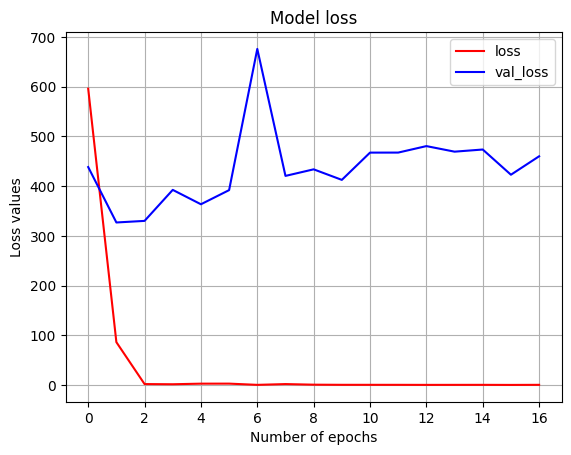

In [16]:
# plot the loss & validation loss
plt.plot(loaded_history['loss'], 'r-', label="loss")
plt.plot(loaded_history['val_loss'], 'b-', label='val_loss')
plt.title("Model loss")
plt.xlabel("Number of epochs")
plt.ylabel('Loss values')
plt.grid()
plt.legend()

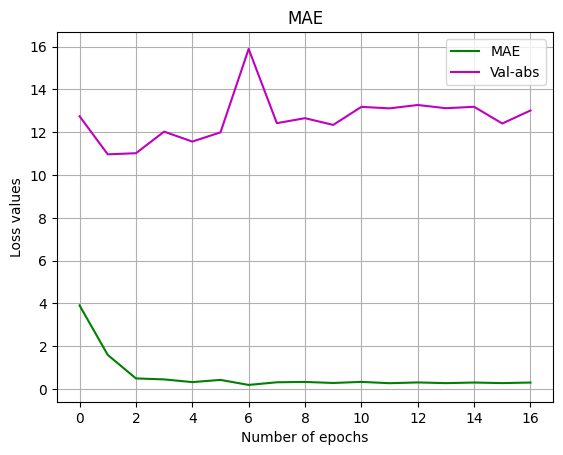

In [14]:
# Plot the Mean Absolute Error & Validation MAE
plt.plot(loaded_history['mae'], 'g-', label="MAE")
plt.plot(loaded_history['val_mae'], 'm-', label="Val-abs")
plt.title("MAE")
plt.xlabel("Number of epochs")
plt.ylabel("Loss values")
plt.grid()
plt.legend()

In [16]:
# Predict the outcome of the test sample and plot the score
y_pred = loaded_model.predict(X_test)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [17]:
# evaluate on testing dataset
loss, mae = loaded_model.evaluate(X_test, y_test)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 327.1128 - mae: 10.9678


In [19]:
loss, mae

(327.1102294921875, 10.967854499816895)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


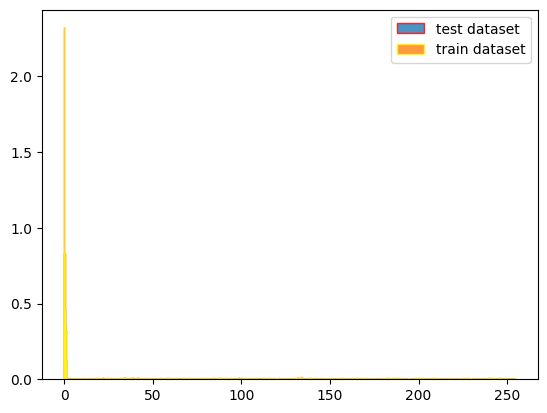

In [17]:
#predict the outcome on the test sample and plot the score
prediction_test = loaded_model.predict(X_test)
plt.hist(prediction_test.flatten(), label='test dataset', alpha=.8, edgecolor='red', bins=np.arange(prediction_test.min(), prediction_test.max() + 0.1, 0.1), density=True)

#predict the outcome on the test sample and plot the score
prediction_train = loaded_model.predict(X_train)
plt.hist(prediction_train.flatten(), label='train dataset', alpha=.8, edgecolor='yellow', bins=np.arange(prediction_test.min(), prediction_test.max() + 0.1, 0.1), density=True)

plt.legend()
plt.show()

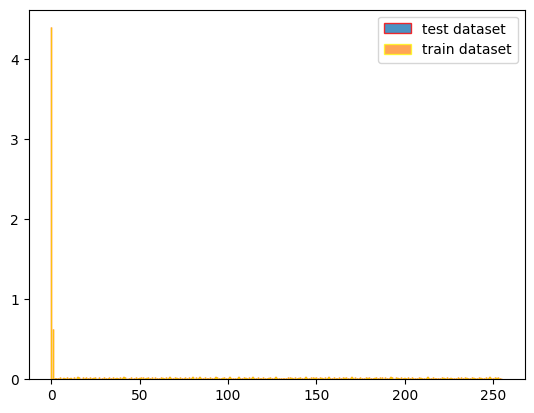

In [20]:
#cast the score to a bool value
prediction_test_rounded = np.round(prediction_test) #cut the score in half
plt.hist(prediction_test_rounded.flatten(), label='test dataset', alpha=.8, edgecolor='red', bins=np.arange(prediction_test_rounded.min(), prediction_test_rounded.max() + 0.2, 0.1), density=True)

prediction_train_rounded = np.round(prediction_train) #cut the score in half
plt.hist(prediction_train_rounded.flatten(), label='train dataset', alpha=.7, edgecolor='yellow', bins=np.arange(prediction_test_rounded.min(), prediction_test_rounded.max() + 0.2, 0.1), density=True)

plt.legend()
plt.show()

In [ ]:
diff_test = abs(prediction_test_rounded - y_test)
print('Accuracy on test data: {}'.format(1 - np.sum(diff_test)/diff_test.size))

diff_train = abs(prediction_train_rounded - y_train)
print('Accuracy on train data: {}'.format(1 - np.sum(diff_train)/diff_train.size))

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, prediction_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
cm = confusion_matrix(y_test, prediction_test_rounded)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.show()